imagenes

In [ ]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('image.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

axs[0].imshow(img_rgb)
axs[0].set_title('Imagen Original')

fig_img=axs[1].imshow(img_rgb[...,0], cmap='gray')
fig.colorbar(fig_img, ax=axs[1], shrink=0.5)
axs[1].set_title('Canal Rojo')

fig_img=axs[2].imshow(img_rgb[...,1], cmap='gray')
fig.colorbar(fig_img, ax=axs[2], shrink=0.5)
axs[2].set_title('Canal Verde')

fig_img=axs[3].imshow(img_rgb[...,2], cmap='gray')
fig.colorbar(fig_img, ax=axs[3], shrink=0.5)
axs[3].set_title('Canal Azul')

In [8]:
img_rgb[:3,:3,:]

array([[[255, 148,  63],
        [255, 148,  61],
        [255, 148,  61]],

       [[255, 148,  61],
        [255, 148,  61],
        [255, 148,  61]],

       [[255, 150,  62],
        [255, 150,  62],
        [255, 150,  62]]], dtype=uint8)

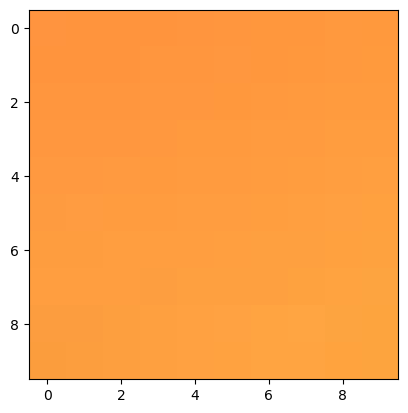

In [9]:
plt.imshow(img_rgb[:10,:10,:])

guardar imagen

In [ ]:
 #GUARDAR IMAGEN CON MATPLOTLIB, SE DEBE CONVERTIR A RGB PARA QUE LOS COLORES SEAN CORRECTOScv2.imwrite('imagen.jpg', img_rgb) #GUARDAR IMAGEN CON OPENCV
plt.imsave('imagen_nueva3.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB))

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['figure.figsize'] = [10, 5]
size_imagen=100
R=np.ones((size_imagen,size_imagen))*225
G=np.ones((size_imagen, size_imagen))*128
B=np.ones((size_imagen, size_imagen))*0

imagen=np.dstack((R,G,B))
imagen=np.array(imagen,dtype=int)

plt.figure()
plt.imshow(imagen)
plt.title('imagen de color: naranja')
plt.show()

Profundidad de color original: uint8
Profundidad de color nueva: uint16


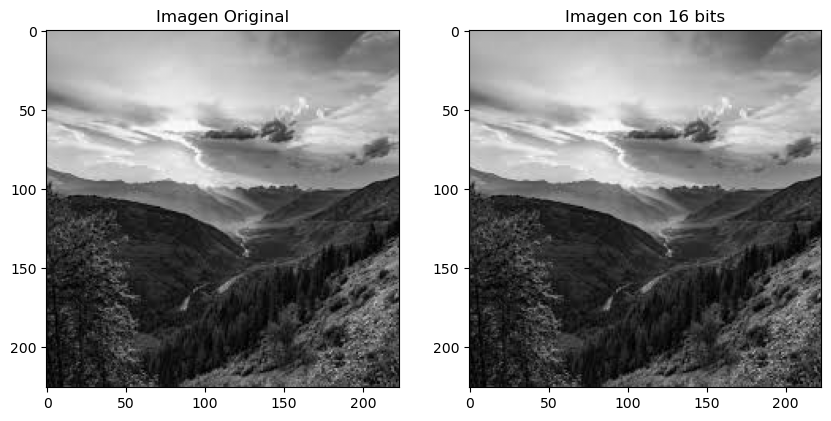

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
img = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)
#VALORES INICIALES DE PROFUNDIDAD DE COLOR
original=img.dtype
#transformando img a 16 bits
img16bits= np.uint16(img)
img_new=img16bits.dtype
print(f'Profundidad de color original: {original}')
print(f'Profundidad de color nueva: {img_new}')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')

plt.subplot(1,2,2)
plt.imshow(img, cmap='gray')
plt.title('Imagen con 16 bits')


cv2.imwrite('imagen_16bits.jpg', img16bits) 
plt.imsave('imagen_nueva_16bits1.jpg', img16bits, cmap='gray')

HSV - RGB

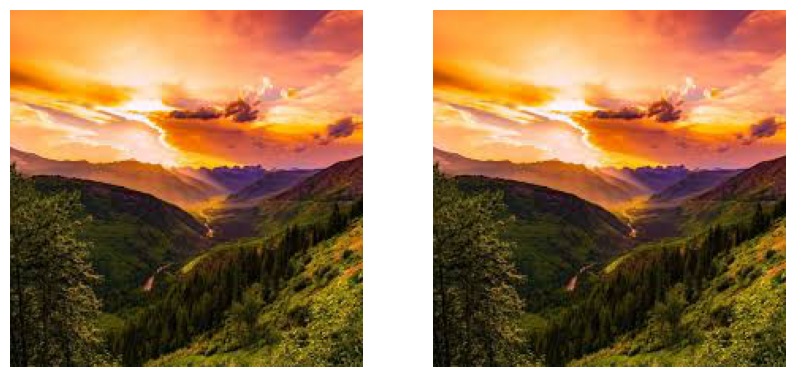

In [26]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def hsv_a_rgb(H, S, V):
    H = H % 360
    C = V * S
    X = C * (1 - abs((H / 60) % 2 - 1))
    m = V - C

    if 0 <= H < 60:
        Rp, Gp, Bp = C, X, 0
    elif 60 <= H < 120:
        Rp, Gp, Bp = X, C, 0
    elif 120 <= H < 180:
        Rp, Gp, Bp = 0, C, X
    elif 180 <= H < 240:
        Rp, Gp, Bp = 0, X, C
    elif 240 <= H < 300:
        Rp, Gp, Bp = X, 0, C
    else:
        Rp, Gp, Bp = C, 0, X

    R = (Rp + m) * 255
    G = (Gp + m) * 255
    B = (Bp + m) * 255

    return int(round(R)), int(round(G)), int(round(B))


def RGB2HSV(img):
    img = img.astype(np.float32) / 255.0
    new_img = np.zeros_like(img)

    maxValue = np.amax(img, axis=2)
    minValue = np.amin(img, axis=2)
    maxChannel = np.argmax(img, axis=2)

    new_img[...,2] = maxValue

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j] == 0:
                new_img[i,j,1] = 0
            else:
                new_img[i,j,1] = (maxValue[i,j] - minValue[i,j]) / maxValue[i,j]

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j] == minValue[i,j]:
                new_img[i,j,0] = 0
            elif maxChannel[i,j] == 0:
                new_img[i,j,0] = 60 * ((img[i,j,1] - img[i,j,2]) / (maxValue[i,j] - minValue[i,j]))
            elif maxChannel[i,j] == 1:
                new_img[i,j,0] = 120 + 60 * ((img[i,j,2] - img[i,j,0]) / (maxValue[i,j] - minValue[i,j]))
            else:
                new_img[i,j,0] = 240 + 60 * ((img[i,j,0] - img[i,j,1]) / (maxValue[i,j] - minValue[i,j]))

    mask = new_img[...,0] < 0
    new_img[...,0][mask] += 360

    return new_img


img = cv2.imread('image.jpg')
if img is None:
    exit()

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_hsv = RGB2HSV(img_rgb)

alto, ancho, _ = img_hsv.shape
rgb_convertido = np.zeros((alto, ancho, 3), dtype=np.uint8)

for i in range(alto):
    for j in range(ancho):
        H = img_hsv[i, j, 0]
        S = img_hsv[i, j, 1]
        V = img_hsv[i, j, 2]
        rgb_convertido[i, j] = hsv_a_rgb(H, S, V)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(rgb_convertido)
plt.axis("off")

plt.show()